# ISLR Python — Chapter 8, Applied Question 12

This notebook completes Applied Question 12 from Chapter 8, Tree-Based Methods. The task is to apply **boosting, bagging, random forests, and BART** to a data set of choice; evaluate each model on a test set; and compare performance against a simple method such as linear regression.

**Data set used:** the scikit-learn Diabetes regression data set.  
**Response variable:** quantitative disease progression measure.  
**Evaluation metrics:** test MSE, RMSE, MAE, and R².

In [27]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pymc as pm
import pymc_bart as pmb

RANDOM_STATE = 42

## 1. Install PyMC-BART if needed

Run this cell only if `pymc` or `pymc_bart` is not installed in your notebook environment. After installation, restart the kernel before running the rest of the notebook.

In [ ]:
# Uncomment and run only if needed.
# !pip install pymc pymc-bart

## 2. Load and split the data

In [24]:
# Load diabetes regression data
X, y = load_diabetes(return_X_y=True, as_frame=True)

# Create a 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

print(f"Training observations: {X_train.shape[0]}")
print(f"Test observations: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
X_train.head()

Training observations: 309
Test observations: 133
Number of predictors: 10


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
225,0.030811,0.050680,0.032595,0.049415,-0.040096,-0.043589,-0.069172,0.034309,0.063015,0.003064
412,0.074401,-0.044642,0.085408,0.063187,0.014942,0.013091,0.015505,-0.002592,0.006207,0.085907
118,-0.056370,0.050680,-0.010517,0.025315,0.023198,0.040022,-0.039719,0.034309,0.020609,0.056912
114,0.023546,-0.044642,0.110198,0.063187,0.013567,-0.032942,-0.024993,0.020655,0.099241,0.023775
364,0.001751,0.050680,-0.006206,-0.019442,-0.009825,0.004949,-0.039719,0.034309,0.014821,0.098333


## 3. Fit simple and tree-based models

The simple baseline model is ordinary least squares linear regression. The tree-based models are bagging, random forest, boosting, and True BART. Bagging fits many decision trees on bootstrap samples; random forest adds random feature selection at each split; boosting sequentially builds shallow trees; and BART uses a Bayesian sum-of-trees model to capture nonlinear effects and interactions.

In [25]:
models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Bagging": BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    "Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.01,
        max_depth=2,
        random_state=RANDOM_STATE
    )
}

In [26]:
def evaluate_predictions(name, y_true, y_pred):
    return {
        "Model": name,
        "Test MSE": mean_squared_error(y_true, y_pred),
        "Test RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "Test MAE": mean_absolute_error(y_true, y_pred),
        "Test R2": r2_score(y_true, y_pred)
    }


def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return evaluate_predictions(name, y_test, y_pred), y_pred


results = []
predictions = {}
fitted_models = {}

for name, model in models.items():
    row, y_pred = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(row)
    predictions[name] = y_pred
    fitted_models[name] = model

base_results_df = pd.DataFrame(results).sort_values("Test MSE").reset_index(drop=True)
base_results_df.round(3)

,Model,Test MSE,Test RMSE,Test MAE,Test R2
0,Linear Regression,2821.751,53.120,41.919,0.477
1,Random Forest,2849.252,53.378,42.853,0.472
2,Boosting,2874.900,53.618,44.084,0.467
3,Bagging,2987.007,54.654,43.602,0.447


## 4. Run True BART with PyMC-BART

This cell fits a true Bayesian Additive Regression Trees model using `pymc_bart`. The posterior mean prediction is stored under the exact model name **`True BART (PyMC-BART)`**, so the later plotting cells can automatically identify and visualize the best model.

In [28]:
BART_MODEL_NAME = "True BART (PyMC-BART)"

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()

with pm.Model() as bart_model:
    X_data = pm.Data("X_data", X_train_np)
    mu = pmb.BART("mu", X=X_data, Y=y_train_np, m=50)
    sigma = pm.HalfNormal("sigma", sigma=np.std(y_train_np))
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_np)

    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        random_seed=RANDOM_STATE,
        progressbar=True
    )

    pm.set_data({"X_data": X_test_np})
    ppc = pm.sample_posterior_predictive(
        idata,
        var_names=["mu"],
        random_seed=RANDOM_STATE,
        progressbar=True
    )

bart_pred = ppc.posterior_predictive["mu"].mean(dim=("chain", "draw")).values
bart_pred = np.asarray(bart_pred).reshape(-1)

# Add True BART to the same objects used by the rest of the notebook.
results.append(evaluate_predictions(BART_MODEL_NAME, y_test, bart_pred))
predictions[BART_MODEL_NAME] = bart_pred
fitted_models[BART_MODEL_NAME] = bart_model

results_df = pd.DataFrame(results).sort_values("Test MSE").reset_index(drop=True)
results_df.round(3)

Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 60 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu]


Output()

,Model,Test MSE,Test RMSE,Test MAE,Test R2
0,True BART (PyMC-BART),2626.107,51.246,40.670,0.514
1,Linear Regression,2821.751,53.120,41.919,0.477
2,Random Forest,2849.252,53.378,42.853,0.472
3,Boosting,2874.900,53.618,44.084,0.467
4,Bagging,2987.007,54.654,43.602,0.447


## 5. Visualize test-set performance

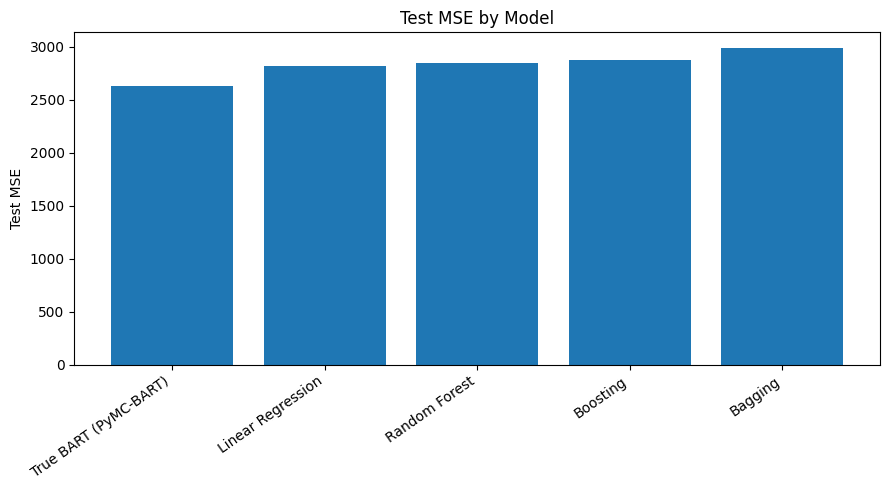

In [29]:
plot_df = results_df.sort_values("Test MSE")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["Model"], plot_df["Test MSE"])
plt.ylabel("Test MSE")
plt.title("Test MSE by Model")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Best model: True BART (PyMC-BART)
Available prediction keys: ['Linear Regression', 'Bagging', 'Random Forest', 'Boosting', 'True BART (PyMC-BART)']


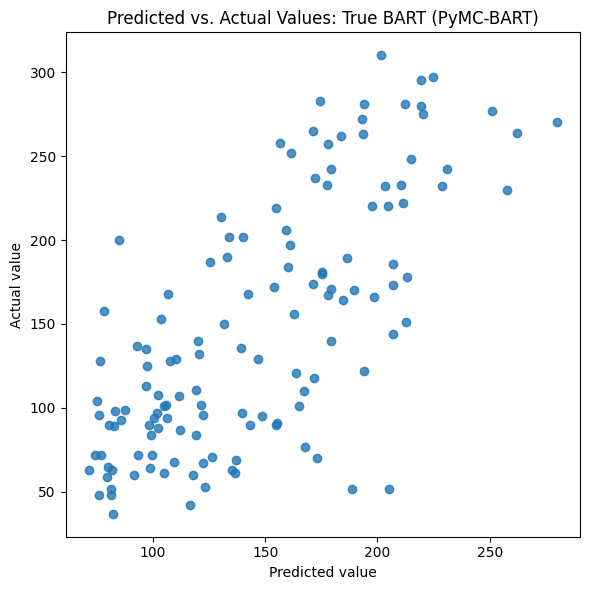

In [30]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)
print("Available prediction keys:", list(predictions.keys()))

best_pred = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(best_pred, y_test, alpha=0.8)
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.title(f"Predicted vs. Actual Values: {best_model_name}")
plt.tight_layout()
plt.show()

## 6. Feature importance for tree-based scikit-learn models

PyMC-BART does not expose `feature_importances_` in the same way as scikit-learn tree ensembles. Therefore, this section reports feature importance for the best-performing scikit-learn tree model that supports `feature_importances_`.

,Feature,Importance
2,bmi,0.2714
8,s5,0.1542
3,bp,0.1265
7,s4,0.0846
9,s6,0.0796
6,s3,0.0756
0,age,0.0706
5,s2,0.0623
4,s1,0.0621
1,sex,0.0129


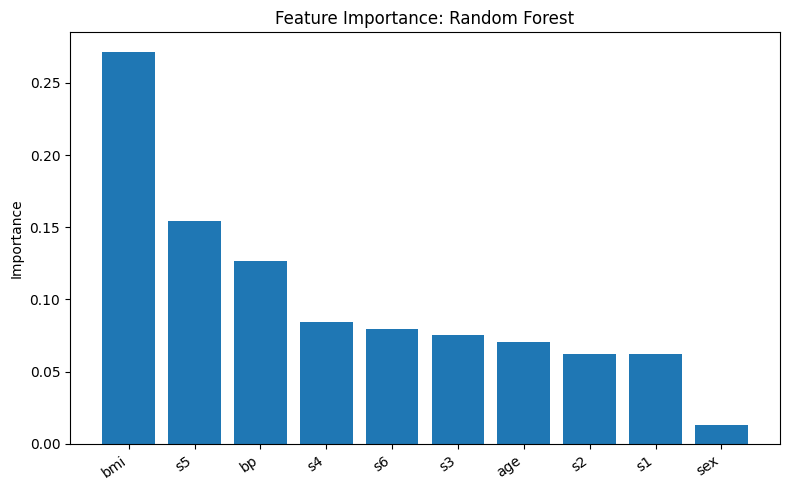

In [31]:
tree_models_with_importance = [
    name for name, model in fitted_models.items()
    if hasattr(model, "feature_importances_")
]

# Choose the best-performing scikit-learn tree model that has feature importances.
best_tree_name = None
for name in results_df["Model"]:
    if name in tree_models_with_importance:
        best_tree_name = name
        break

if best_tree_name is not None:
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": fitted_models[best_tree_name].feature_importances_
    }).sort_values("Importance", ascending=False)
    display(importance.round(4))

    plt.figure(figsize=(8, 5))
    plt.bar(importance["Feature"], importance["Importance"])
    plt.ylabel("Importance")
    plt.title(f"Feature Importance: {best_tree_name}")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No fitted scikit-learn tree model with feature_importances_ was found.")